# W06 · Inverse and Hierarchical RL — Reward Recovery and a Node-Level Semi-MDP

Hongyu LIU · InGen Dynamics — ML & NN Analyst Intern, July 2026

**Platform:** Aido Rover · Origami / PIC 2.0 (HTD-IRL)
**Protocol:** 5 train seeds (0–4) × 10 fixed evaluation world seeds · γ = 0.99 and γ = 1.0 as crossed arms · **Deployment gate:** ≤100 ms patrol inference

Two questions in one notebook. Can the reward be recovered from logged expert behaviour, and how far
does the recovery degrade when the features available to the learner are poorer than the ones the
expert acted on? And does raising the decision level from 10 Hz actions to route-node options repair
the navigational failure Week 5 diagnosed — and if so, through which mechanism?

In [1]:
import json, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
torch.set_num_threads(1)

from shared_modules.rl_eval import ART_DIR, EVAL_WORLD_SEEDS, W5_EVAL_SEEDS, N_TRAIN_SEEDS, \
    W6_TIMESTEPS, GAMMA, verify_w5_reference_gate, paired_test

SEED = 42
BLUE, ORANGE, GREEN, RED, GREY = '#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8C8C8C'
IMG_DIR = Path('../reports/image/W06_IRL_Hierarchical'); IMG_DIR.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    fig.savefig(IMG_DIR / name, bbox_inches='tight', dpi=130)


from rl import irl as IRL
from rl.rover_options_env import RoverOptionsEnv, OPTION_NAMES, make_scripted_option_predict
from shared_modules.rl_eval import make_scripted_predict, ExpertAware, evaluate

print('options       ', OPTION_NAMES)
print('IRL axes      ', IRL.AXES, '->', IRL.N_CELLS, 'cells')

options        {0: 'patrol-edge', 1: 'reroute-branch', 2: 'slow-traverse', 3: 'dock'}
IRL axes       ('label', 'halted', 'main_blocked', 'branch_blocked', 'rough', 'low_soc', 'tstd_bin') -> 192 cells


## 1. The Route Geometry, Measured

Week 5 attributed the failure to reroute to a horizon problem. Quantifying the geometry before
building the hierarchy showed the diagnosis needed splitting, so the numbers come first.

In [2]:
env = RoverOptionsEnv(randomize_reset=False, seed=0)
obs, info = env.reset()
rows = []
for opt in [0, 0, 2, 0]:
    obs, r, term, trunc, i = env.step(opt)
    rows.append(dict(option=OPTION_NAMES[opt], k_env_steps=i['option_k'],
                     option_reward=round(r, 3), raw_sum=round(i.get('reward_sum', float('nan')), 1),
                     gamma_k=f"{GAMMA ** i['option_k']:.2e}"))
    if term or trunc: break
env.close()
pd.DataFrame(rows)

,option,k_env_steps,option_reward,raw_sum,gamma_k
0,patrol-edge,1707,151.927,2745.6,3.54e-08
1,patrol-edge,668,121.984,821.6,1.21e-03
2,slow-traverse,3081,-12.804,778.8,3.56e-14
3,patrol-edge,647,167.086,1161.7,1.50e-03


A sweep edge is 1,700–1,900 environment steps and only the short connectors are ~600. With
`γ = 0.99`, `γᵏ` at an option boundary is of order 10⁻⁸, so the bootstrap term in the semi-MDP backup

`Q(s,o) = Σ_{t<k} γᵗ r_t + γᵏ · E[max_o' Q(s',o')]`

is annihilated. **A semi-MDP at the same γ optimises exactly the flat objective**; it does not lengthen
the horizon, and the Week-5 statement of a ~95-point dead-end cost was an undiscounted accounting that
both formulations discount away identically.

What the hierarchy changes is where the signal sits relative to a learning update. The difference
between a clean edge and one whose blockage matters is present *inside* the option return, and the
option learner attaches it to a single backup where the flat learner must propagate it through ~1,700
bootstrapped TD steps. The two effects are therefore separated below: γ = 0.99 holds the objective
identical to the flat MDP and isolates credit assignment; γ = 1.0 uses the episode cap as the horizon
and lets the terminal cost become visible.

In [3]:
edges = []
for ws in EVAL_WORLD_SEEDS:
    e = RoverOptionsEnv(randomize_reset=False, seed=ws)
    o, i = e.reset()
    while True:
        o, r, term, trunc, i = e.step(0)
        # an edge counts as "blockage ahead" if the single-block condition held on any of its steps
        edges.append(dict(r=r, raw=i['reward_sum'], k=i['option_k'],
                          blocked=i['events']['single_block'] > 0))
        if term or trunc:
            break
    e.close()
edges = pd.DataFrame(edges)


def edge_summary(df):
    parts = [('clean', df[~df.blocked]), ('blockage ahead', df[df.blocked])]
    return pd.DataFrame([dict(edge=name, n=len(g), discounted=g.r.mean(),
                              undiscounted=g.raw.mean(), k_env_steps=g.k.mean())
                         for name, g in parts]).round(1)


# Pooling the ~600-step connectors with the 1,700-1,900-step sweeps mixes two edge lengths into
# one mean; the like-for-like comparison conditions on sweep edges (k > 1,500), where clean and
# blocked edges run the same distance and the difference is the blockage alone.
print('all edges pooled')
display(edge_summary(edges))
print('sweep edges only (k > 1,500)')
edge_summary(edges[edges.k > 1500])

all edges pooled


,edge,n,discounted,undiscounted,k_env_steps
0,clean,37,133.1,1564.4,1117.5
1,blockage ahead,13,119.0,1494.6,1162.6


sweep edges only (k > 1,500)


,edge,n,discounted,undiscounted,k_env_steps
0,clean,14,119.2,2493.6,1774.7
1,blockage ahead,6,131.4,2411.0,1790.0


## 2. Option Controllers and the Semi-MDP

Four options, each running to the next route node with the reactive layer intact at 10 Hz underneath:
`patrol-edge`, `reroute-branch`, `slow-traverse`, `dock`. The controllers are the Week-5 rule policy
restricted to a single edge, so what the option-level learner chooses is the routing, not the reactive
behaviour.

**Why not frame-skip.** Frame-skip would lower the decision rate uniformly, slowing alerting as well —
and the Aido Rover's ≤100 ms detection gate requires the reactive layer to stay at 10 Hz. Options
lower only the routing rate. The product constraint selects the design, not a preference.

**A caveat that must be stated before any number is read.** The option controller alerts on the
ground-truth label, so the scripted option policy sits in the *privileged* bracket next to the
label-aware expert, not next to the deployable rule policy. On the ten-world protocol every table
below uses, the bracket is floor 3,931 / ceiling 11,575; the Week-5 figures 4,072 and 12,199 are the
same policies on Week 5's five-world subset and appear only in the reproduction gate. Its return must
be read against the ceiling.

In [4]:
sc_opt = make_scripted_option_predict()
opt_sum = json.loads((ART_DIR / 'evalopt_scripted_option.json').read_text())
_, flat_sum = evaluate(make_scripted_predict())
_, exp_sum = evaluate(ExpertAware(), env_aware=True)
cols = ('return_mean', 'return_std', 'p_reroute_block')
pd.DataFrame([
    dict(policy='flat scripted, label-blind (floor)', **{k: flat_sum[k] for k in cols}),
    dict(policy='scripted option policy (privileged controller)', **{k: opt_sum[k] for k in cols}),
    dict(policy='flat expert, label-aware (ceiling)', **{k: exp_sum[k] for k in cols}),
]).round(3)

,policy,return_mean,return_std,p_reroute_block
0,"flat scripted, label-blind (floor)",3930.605,615.864,1.000
1,scripted option policy (privileged controller),10853.410,2291.401,0.520
2,"flat expert, label-aware (ceiling)",11574.590,1343.220,0.871


## 3. Learned Option-Level Policy

The tabular high-level learner sees a small state (SoC band, blockage flags, terrain flag) and four
options. A 250,000-step budget buys roughly 250,000 flat actions or roughly 250 option decisions, and
the comparison below is between those two uses of the same environment interaction.

In [5]:
def load_option_evals():
    """Option-level results, which live in their own files because the env differs."""
    out = {}
    for p in ART_DIR.glob('evalopt_*.json'):
        d = json.loads(p.read_text())
        out[d['tag']] = d
    return out


DISPLAY_OPTIONS = [
    ('scripted_option', 'scripted option policy (no learning)'),
    ('options_smdp', 'SMDP learner, γ = 0.99, 250k'),
    ('options_smdp_g1', 'SMDP learner, γ = 1.0, 250k'),
    ('options_smdp_1m', 'SMDP learner, γ = 0.99, 1M'),
    ('options_smdp_g1_1m', 'SMDP learner, γ = 1.0, 1M'),
]


def _f(v, nd=2):
    return '—' if v is None or (isinstance(v, float) and v != v) else f'{v:.{nd}f}'


def option_table(oe, order=None):
    rows = []
    for tag, label in (order or DISPLAY_OPTIONS):
        d = oe.get(tag)
        if d is None:
            continue
        rows.append({'policy': label, 'n seeds': d['n_train_seeds'],
                     'return': f"{d['return_mean']:.0f} ± {d['return_std']:.0f}",
                     'ep len': f"{d.get('len_mean', float('nan')):.0f}",
                     'decisions/ep': _f(d.get('n_options_mean'), 1),
                     'P(reroute|block)': _f(d.get('p_reroute_block')),
                     'dock-ended': _f(d.get('dock_episode_rate')),
                     'stuck-ended': _f(d.get('stuck_rate'))})
    return pd.DataFrame(rows)


def opt_meta(tag, n=5):
    return [json.loads((ART_DIR / f'{tag}_s{s}_meta.json').read_text())
            for s in range(n) if (ART_DIR / f'{tag}_s{s}_meta.json').exists()]


oe = load_option_evals()
tbl = option_table(oe)
tbl['train decisions'] = [int(np.mean([d['decisions'] for d in opt_meta(t)] or [0]))
                          for t, _ in DISPLAY_OPTIONS if t in oe]
display(tbl)
print('flat-MDP reference on the same worlds: DQN 250k reroutes on 0.04-0.09 of single blockages, '
      'BC-initialised PPO on 0.34')

,policy,n seeds,return,ep len,decisions/ep,P(reroute|block),dock-ended,stuck-ended,train decisions
0,scripted option policy (no learning),1,10853 ± 2291,7876,7.7,0.52,0.00,0.60,0
1,"SMDP learner, γ = 0.99, 250k",5,10044 ± 2066,7270,8.2,0.49,0.00,0.68,263
2,"SMDP learner, γ = 1.0, 250k",5,11276 ± 586,8152,9.8,0.74,0.02,0.50,284
3,"SMDP learner, γ = 0.99, 1M",5,10651 ± 1679,7726,8.3,0.55,0.00,0.60,1020
4,"SMDP learner, γ = 1.0, 1M",5,12129 ± 121,8844,10.2,0.82,0.00,0.40,1089


flat-MDP reference on the same worlds: DQN 250k reroutes on 0.04-0.09 of single blockages, BC-initialised PPO on 0.34


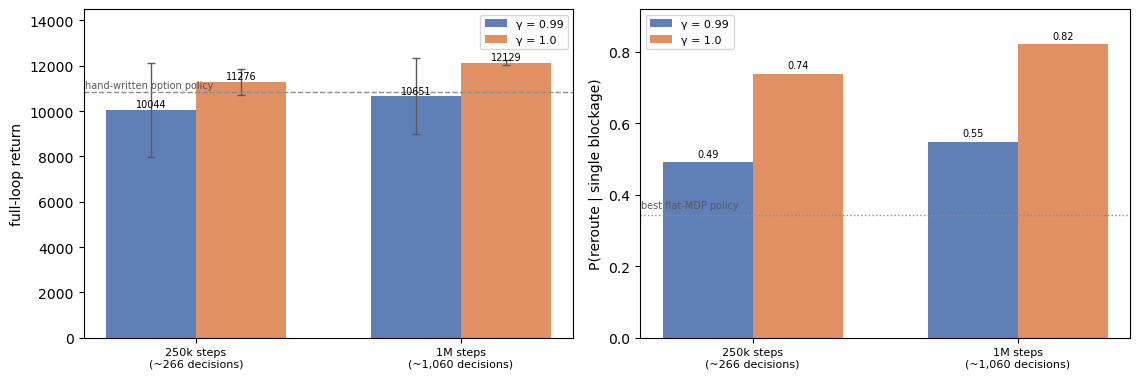

return   discount effect +1232.232 at 250k, +1477.974 at 1M | budget effect +607.740 at γ=0.99, +853.482 at γ=1.0
reroute  discount effect   +0.247 at 250k,   +0.273 at 1M | budget effect   +0.057 at γ=0.99,   +0.083 at γ=1.0


In [6]:
def load_eval(path=None):
    return json.loads(Path(path or ART_DIR / 'w6_eval.json').read_text())


ev_flat = load_eval()


# Two decision budgets crossed with two discounts. Grouped bars rather than a line, because two
# x-values connected by a segment would imply a trend that four points cannot support.
ARMS = [(0.99, ['options_smdp', 'options_smdp_1m'], BLUE),
        (1.0, ['options_smdp_g1', 'options_smdp_g1_1m'], ORANGE)]
BUDGETS = ['250k steps\n(~266 decisions)', '1M steps\n(~1,060 decisions)']

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
w, x = 0.34, np.arange(2)
for i, (g, tags, c) in enumerate(ARMS):
    ret = [oe[t]['return_mean'] for t in tags]
    err = [oe[t]['return_std'] for t in tags]
    rer = [oe[t]['p_reroute_block'] for t in tags]
    axes[0].bar(x + (i - 0.5) * w, ret, w, yerr=err, color=c, alpha=0.9, label=f'γ = {g}',
                error_kw=dict(lw=1, ecolor='0.35', capsize=3))
    axes[1].bar(x + (i - 0.5) * w, rer, w, color=c, alpha=0.9, label=f'γ = {g}')
    for xi, (v, rv) in enumerate(zip(ret, rer)):
        axes[0].text(xi + (i - 0.5) * w, v + 120, f'{v:.0f}', ha='center', fontsize=7)
        axes[1].text(xi + (i - 0.5) * w, rv + 0.015, f'{rv:.2f}', ha='center', fontsize=7)

axes[0].axhline(oe['scripted_option']['return_mean'], ls='--', color=GREY, lw=1)
axes[0].text(-0.42, oe['scripted_option']['return_mean'] + 150, 'hand-written option policy',
             fontsize=7, color='0.35')
axes[0].set_ylabel('full-loop return'); axes[0].set_ylim(0, 14500)
axes[1].axhline(ev_flat['ppo250k_bcinit']['p_reroute_block'], ls=':', color=GREY, lw=1)
axes[1].text(-0.42, ev_flat['ppo250k_bcinit']['p_reroute_block'] + 0.02,
             'best flat-MDP policy', fontsize=7, color='0.35')
axes[1].set_ylabel('P(reroute | single blockage)'); axes[1].set_ylim(0, 0.92)
for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(BUDGETS, fontsize=8); ax.legend(fontsize=8)
plt.tight_layout(); save(fig, 'hierarchy_factorial.png'); plt.show()

for key, lab in [('return_mean', 'return'), ('p_reroute_block', 'reroute')]:
    lo = [oe[t][key] for t in ARMS[0][1]]; hi = [oe[t][key] for t in ARMS[1][1]]
    print(f'{lab:8s} discount effect {hi[0]-lo[0]:+8.3f} at 250k, {hi[1]-lo[1]:+8.3f} at 1M | '
          f'budget effect {lo[1]-lo[0]:+8.3f} at γ=0.99, {hi[1]-hi[0]:+8.3f} at γ=1.0')

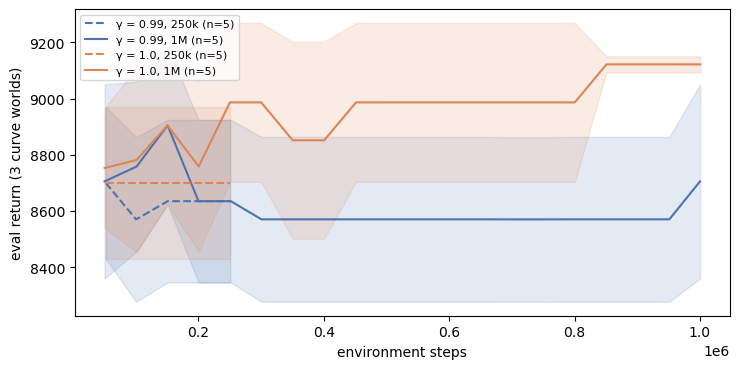

In [7]:
# The endpoint bars above hide the trajectory; the harness evaluated every run each ~50k steps
# (full 9,600-step loop), so the curves come free from the training metas. Bands are ±1 std
# across train seeds. The curve worlds carry no reroute rate (no single-blockage event occurs
# on them), so the curve is return only; absolute levels are not comparable with the ten-world
# tables above, since the curve runs on the three curve worlds.
OPT_ARMS = [('options_smdp', 'γ = 0.99, 250k', BLUE, '--'),
            ('options_smdp_1m', 'γ = 0.99, 1M', BLUE, '-'),
            ('options_smdp_g1', 'γ = 1.0, 250k', ORANGE, '--'),
            ('options_smdp_g1_1m', 'γ = 1.0, 1M', ORANGE, '-')]


def opt_curves(tag):
    ts, res = None, []
    for m in opt_meta(tag):
        c = m.get('curve') or {}
        if not c.get('results'):
            continue
        if ts is None or len(c['timesteps']) < len(ts):
            ts = c['timesteps']
        res.append(c['results'])
    if not res:
        return None, None
    k = min(len(r) for r in res)
    return np.array(ts[:k]), np.array([r[:k] for r in res], dtype=float)


fig, ax = plt.subplots(figsize=(7.5, 3.8))
for tag, lab, c, ls in OPT_ARMS:
    ts, cur = opt_curves(tag)
    if ts is None:
        continue
    m, sd = cur.mean(0), cur.std(0)
    ax.plot(ts, m, color=c, ls=ls, label=f'{lab} (n={len(cur)})')
    ax.fill_between(ts, m - sd, m + sd, alpha=0.15, color=c)
ax.set_xlabel('environment steps')
ax.set_ylabel('eval return (3 curve worlds)')
ax.legend(fontsize=8)
plt.tight_layout(); save(fig, 'options_learning_curves.png'); plt.show()

In [8]:
# The ten-world protocol exists so that every "A beats B" claim carries a paired Wilcoxon; the
# option arms were the one family exempted, because their eval files stored only aggregates.
# With per-world returns in the artifacts, the factorial effects get the same test as the flat
# families. The paired vector is the per-world mean across train seeds, as in §3 of the PG notebook.
def opt_per_world(tag):
    return np.array(oe[tag]['per_seed_per_world']).mean(0)


FACT_PAIRS = [
    ('discount effect at 250k', 'options_smdp_g1', 'options_smdp'),
    ('discount effect at 1M', 'options_smdp_g1_1m', 'options_smdp_1m'),
    ('budget effect at γ = 0.99', 'options_smdp_1m', 'options_smdp'),
    ('budget effect at γ = 1.0', 'options_smdp_g1_1m', 'options_smdp_g1'),
    ('best arm vs scripted option policy', 'options_smdp_g1_1m', 'scripted_option'),
]
rows = []
for name, a, b in FACT_PAIRS:
    t = paired_test(opt_per_world(a), opt_per_world(b))
    rows.append({'comparison': name, 'A': a, 'B': b,
                 'Δ return (A−B)': round(t['delta'], 1), 'p': round(t['p'], 4),
                 'significant': t['significant']})
pd.DataFrame(rows)

,comparison,A,B,Δ return (A−B),p,significant
0,discount effect at 250k,options_smdp_g1,options_smdp,1232.2,0.0137,True
1,discount effect at 1M,options_smdp_g1_1m,options_smdp_1m,1478.0,0.0020,True
2,budget effect at γ = 0.99,options_smdp_1m,options_smdp,607.7,0.0273,True
3,budget effect at γ = 1.0,options_smdp_g1_1m,options_smdp_g1,853.5,0.0371,True
4,best arm vs scripted option policy,options_smdp_g1_1m,scripted_option,1275.9,0.0645,False


## 4. The Low-SoC Ablation, Where It Is Reachable

Week 5 prescribed a per-step low-SoC penalty as the fix for a reward under which no agent ever docks.
Running it exposed a prerequisite the prescription did not state: discharge is about 0.004 % of SoC per
step, so reaching 20 % from a full battery takes ~19,500 steps — twice the evaluation loop — and
training resets draw SoC from U(40, 100) under a 2,400-step cap that bottoms out near 30 %. No agent
ever entered the region the penalty governs. The ablation is therefore run from a lowered dispatch
charge, U(18, 30), with a matching evaluation start; and at the option level, docking is a single
decision rather than an event 6,000 discounted steps away.

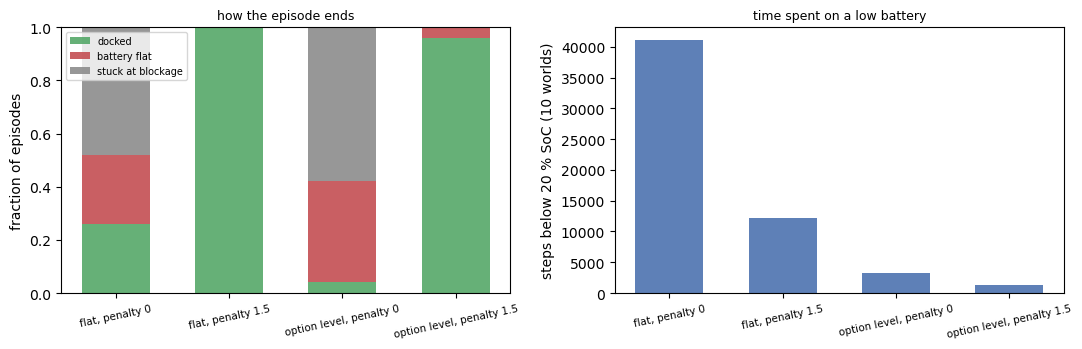

,config,n seeds,return,ep len,low-SoC steps,dock-ended episodes,per-step dock rate
0,"flat PPO, penalty 0.0",5,142 ± 13,322,0,1.00,—
1,"flat PPO, penalty 1.5",5,147 ± 14,314,0,1.00,—
2,"flat PPO BC-init, penalty 0.0",5,5190 ± 729,6660,41093,0.26,0.0001
3,"flat PPO BC-init, penalty 1.5",5,998 ± 669,3761,12257,1.00,0.0010
4,"option level, penalty 0.0",5,7863 ± 142,5682,3218,0.04,0.0000
5,"option level, penalty 1.5",5,3350 ± 129,3709,1244,0.96,0.0011


In [9]:
# Ablation arms are tabled separately from the main ladder: they run on a different dispatch charge
# or a different discount, so their returns are not comparable with the rows above.
DISPLAY_LOWSOC = [
    ('ppo_lowsoc_c0', 'flat PPO, penalty 0.0'),
    ('ppo_lowsoc_c15', 'flat PPO, penalty 1.5'),
    ('ppo_lowsoc_c0_bcinit', 'flat PPO BC-init, penalty 0.0'),
    ('ppo_lowsoc_c15_bcinit', 'flat PPO BC-init, penalty 1.5'),
    ('options_lowsoc_c0', 'option level, penalty 0.0'),
    ('options_lowsoc_c15', 'option level, penalty 1.5'),
]


def lowsoc_table(ev, oe):
    """The low-SoC ablation, pooled across the flat and option-level arms."""
    rows = []
    for tag, label in DISPLAY_LOWSOC:
        d = ev.get(tag) or oe.get(tag)
        if d is None:
            continue
        rows.append({'config': label, 'n seeds': d['n_train_seeds'],
                     'return': f"{d['return_mean']:.0f} ± {d['return_std']:.0f}",
                     'ep len': f"{d.get('len_mean', float('nan')):.0f}",
                     'low-SoC steps': _f(d.get('low_soc_steps'), 0),
                     'dock-ended episodes': _f(d.get('dock_episode_rate')),
                     'per-step dock rate': _f(d.get('dock_rate'), 4)})
    return pd.DataFrame(rows)


def fig_lowsoc(ev, oe):
    """How each low-SoC arm ends its episodes, and how long it spends below the threshold."""
    arms = [('ppo_lowsoc_c0_bcinit', ev, 'flat, penalty 0'),
            ('ppo_lowsoc_c15_bcinit', ev, 'flat, penalty 1.5'),
            ('options_lowsoc_c0', oe, 'option level, penalty 0'),
            ('options_lowsoc_c15', oe, 'option level, penalty 1.5')]
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    keys = [('dock_episode_rate', 'docked', GREEN), ('soc_depleted_rate', 'battery flat', RED),
            ('stuck_rate', 'stuck at blockage', GREY)]
    bottom = np.zeros(len(arms))
    for k, lab, c in keys:
        v = np.array([float(src[t].get(k) or 0.0) for t, src, _ in arms])
        axes[0].bar(range(len(arms)), v, 0.6, bottom=bottom, color=c, alpha=0.9, label=lab)
        bottom += v
    axes[0].set_ylabel('fraction of episodes')
    axes[0].set_title('how the episode ends', fontsize=9)
    axes[0].legend(fontsize=7)
    soc = [float(src[t].get('low_soc_steps') or 0.0) for t, src, _ in arms]
    axes[1].bar(range(len(arms)), soc, 0.6, color=BLUE, alpha=0.9)
    axes[1].set_ylabel('steps below 20 % SoC (10 worlds)')
    axes[1].set_title('time spent on a low battery', fontsize=9)
    for ax in axes:
        ax.set_xticks(range(len(arms)))
        ax.set_xticklabels([lab for _, _, lab in arms], fontsize=7.5, rotation=12)
    fig.tight_layout()
    save(fig, 'lowsoc_ablation.png')
    return fig


fig_lowsoc(ev_flat, oe); plt.show()
lowsoc_table(ev_flat, oe)

A per-environment-step docking rate is the wrong statistic at option granularity: `dock` is one
decision against the thousands of low-SoC environment steps it terminates, so the ratio is ~1/2000
whatever the policy does. The column that carries the ablation is the fraction of episodes that
*ended* by docking.

## 5. Inverse RL — Recovering the Reward from Logged Behaviour

The generating reward here is known exactly and is a small table, so unlike a typical IRL
demonstration this one can be scored rather than inspected. `compute_reward` is linear in indicator
features over `(label, action, halted, main_blocked, rough, soc<20)`, so an IRL run given those
indicators should recover it almost exactly — and that is the control experiment.

**A linear reward is identifiable only up to a positive affine transformation**, since scaling and
shifting `r` leaves every policy ordering unchanged. Pearson and Spearman are themselves invariant
under that freedom, so the correlations below are unaffected by the arbitrary scale; the affine fit
exists to place the recovered values on the true reward's scale for the figure and to report what
remains (`affine R²`) once the free scale and shift are spent.

**Two feature sets.** `priv` includes the ground-truth label indicator. `obs` replaces it with an
observable proxy — a `torque_std` bucket, since the anomaly signature is torque *variability* rather
than mean (terrain confounds the mean; wet grass baselines above 30 Nm). The expert is privileged and
alerts on the true label, so a non-privileged feature set cannot represent the rule it is imitating.
The degradation between the two is the result, and it is the same information gap that caps behaviour
cloning's alert recall at 0.50 in Week 5.

In [10]:
mdp = IRL.build_tabular_mdp()
res = {fs: IRL.run_maxent_irl(mdp, feature_set=fs) for fs in ('priv', 'obs')}
val = {fs: IRL.validate(res[fs], mdp) for fs in res}

rows = []
for fs in ('priv', 'obs'):
    r, p = val[fs]['reward'], val[fs]['policy']
    rows.append({'feature set': fs, 'Pearson': r['pearson'], 'Spearman': r['spearman'],
                 'Pearson (supported cells)': r['pearson_supported'],
                 'affine R²': r['affine_r2'],
                 'online return': f"{p['return_mean']:.0f} ± {p['return_std']:.0f}",
                 'frac of floor→ceiling': p['frac_of_range'],
                 'bracketed': p['bracketed'],
                 'P(alert|anom)': p['p_alert_anomaly'],
                 'false alerts /1k': p['false_alerts_per_1k']})
display(pd.DataFrame(rows).round(3))
print(f"floor {val['priv']['policy']['floor']:.0f}   ceiling {val['priv']['policy']['ceiling']:.0f}")
print(f"soft value iteration: {val['priv']['soft_vi_iters']} sweeps to residual "
      f"{val['priv']['soft_vi_residual']:.1e}")

,feature set,Pearson,Spearman,Pearson (supported cells),affine R²,online return,frac of floor→ceiling,bracketed,P(alert|anom),false alerts /1k
0,priv,0.458,0.309,0.559,0.210,11285 ± 2267,0.962,True,1.000,0.183
1,obs,-0.023,0.080,-0.008,0.001,2423 ± 1266,-0.197,False,0.118,103.324


floor 3931   ceiling 11575
soft value iteration: 2214 sweeps to residual 1.0e-09


The positive control separates a broken fitter from an unidentified problem: refitting with the expert
replaced by the soft-optimal policy under the true reward — same code, same features, same occupancy
solve, same MDP — recovers the reward at Pearson 0.947 / Spearman 0.970 against 0.458 / 0.309 from the
logged demonstrations.

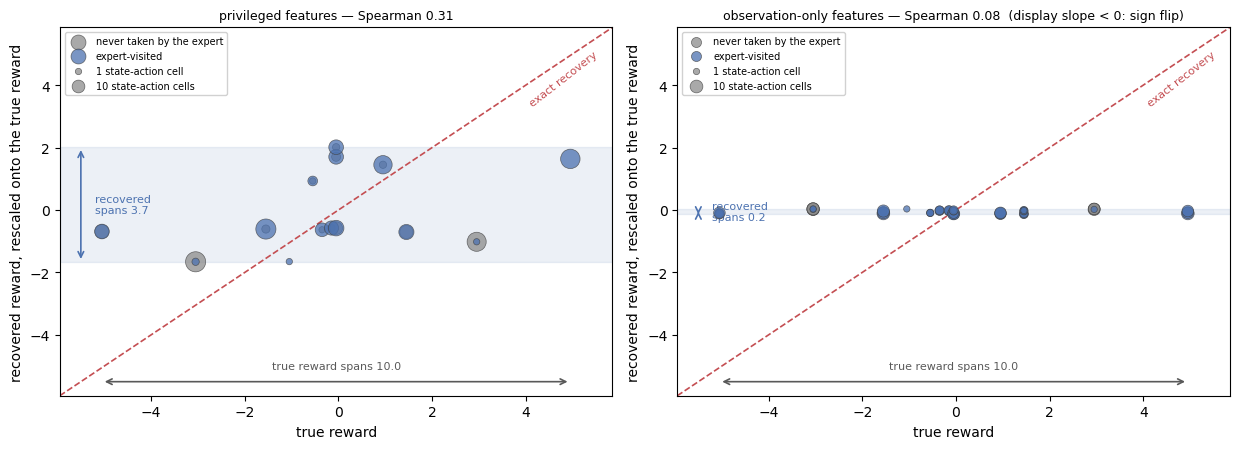

In [11]:
# The recovered values are mapped onto the true reward's scale by an unconstrained least-squares
# affine fit before plotting; exact recovery then lies on y = x, and the vertical extent of the
# point cloud against the diagonal is what the fit lost. For a fit this weak the least-squares
# slope can come out negative — outside the positive-affine family the identifiability argument
# licenses — so a negative slope is flagged on the panel rather than hidden.
true_R = np.asarray(IRL.true_reward_table(mdp)).ravel()
vis = np.asarray(mdp['expert_visit']).ravel()
span_true = true_R.max() - true_R.min()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
for ax, fs, name in [(axes[0], 'priv', 'privileged features'),
                     (axes[1], 'obs', 'observation-only features')]:
    r = np.asarray(res[fs]['reward']).ravel()
    a, b = val[fs]['reward']['affine_alpha'], val[fs]['reward']['affine_beta']
    corrected = a * r + b
    lo, hi = corrected.min(), corrected.max()
    flip = '  (display slope < 0: sign flip)' if a < 0 else ''

    lim = [true_R.min() - 0.9, true_R.max() + 0.9]
    ax.plot(lim, lim, ls='--', lw=1.2, color=RED, zorder=1)
    ax.text(lim[1] - 0.3, lim[1] - 0.9, 'exact recovery', color=RED, fontsize=8,
            ha='right', rotation=38, rotation_mode='anchor')

    # the band the fit actually produces, against the range it was trying to reproduce
    ax.axhspan(lo, hi, color=BLUE, alpha=0.10, zorder=0)
    ax.annotate('', xy=(lim[0] + 0.45, lo), xytext=(lim[0] + 0.45, hi),
                arrowprops=dict(arrowstyle='<->', color=BLUE, lw=1.2))
    ax.text(lim[0] + 0.75, (lo + hi) / 2, f'recovered\nspans {hi - lo:.1f}',
            fontsize=8, color=BLUE, va='center')
    ax.annotate('', xy=(true_R.min(), lim[0] + 0.45), xytext=(true_R.max(), lim[0] + 0.45),
                arrowprops=dict(arrowstyle='<->', color='0.35', lw=1.2))
    ax.text((true_R.min() + true_R.max()) / 2, lim[0] + 0.85,
            f'true reward spans {span_true:.1f}', fontsize=8, color='0.35', ha='center')

    for mask, c, lab in [(vis == 0, GREY, 'never taken by the expert'), (vis > 0, BLUE, 'expert-visited')]:
        if not mask.any():
            continue
        pts, cnt = np.unique(np.round(np.c_[true_R[mask], corrected[mask]], 3), axis=0, return_counts=True)
        ax.scatter(pts[:, 0], pts[:, 1], s=14 + 7 * cnt, color=c, alpha=0.75,
                   edgecolor='0.25', lw=0.5, zorder=3, label=lab)
    for n in (1, 10):                                   # marker-size key
        ax.scatter([], [], s=14 + 7 * n, color=GREY, alpha=0.75, edgecolor='0.25', lw=0.5,
                   label=f'{n} state-action cell' + ('s' if n > 1 else ''))

    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('true reward')
    ax.set_ylabel('recovered reward, rescaled onto the true reward')
    ax.set_title(f"{name} — Spearman {val[fs]['reward']['spearman']:.2f}{flip}", fontsize=9)
    ax.legend(fontsize=7, loc='upper left', framealpha=0.9)
plt.tight_layout(); save(fig, 'irl_recovery.png'); plt.show()

## 6. Hierarchical Task Decomposition — the Quadrotor Analogy

The option layer here is the same decomposition the quadrotor local planner uses, and the reason is
the same. That planner replans a trajectory roughly every 80 ms, but the decision it is really making
— which corridor to commit to — changes far more slowly than the trajectory it emits, so the
architecture separates a slow discrete commitment from a fast continuous controller. Attempting the
corridor choice at control rate would put the consequence of a commitment thousands of control steps
after the decision that caused it, which is exactly the credit-assignment distance measured in §1.

The transfer is in the decomposition, not in the horizon argument. The quadrotor planner truncates its
own horizon deliberately, and the rover semi-MDP does not extend one; both gain by attaching a decision
to the level at which its consequence is observable.

## 7. Deployment Latency — a Two-Level Inference Path

The single-MLP latency conclusion from Phase B does not transfer automatically to a hierarchy, because
a step now runs a high-level lookup plus a low-level controller. Both are measured.

In [12]:
import timeit
from rl.harness.evaluate import load_table_policy

sc_flat = make_scripted_predict()
obs9 = np.zeros(9, dtype=np.float32)
t_low = timeit.timeit(lambda: sc_flat(obs9), number=5000) / 5000
t_high = timeit.timeit(lambda: sc_opt(obs9), number=5000) / 5000
# the two policies the sections above actually report: the learned Q-table selection and the
# observation-only IRL policy (the privileged variant needs the env's label and has no
# standalone inference path)
q_pred = load_table_policy('options_smdp_g1_1m', 0)
t_q = timeit.timeit(lambda: q_pred(obs9), number=5000) / 5000
irl_pred = IRL.make_predict(res['obs'], mdp)
t_irl = timeit.timeit(lambda: irl_pred(obs9), number=5000) / 5000
lat = pd.DataFrame([
    dict(path='low-level controller (per 10 Hz step)', ms=1000 * t_low),
    dict(path='high-level option selection (per node)', ms=1000 * t_high),
    dict(path='worst-case step: both levels', ms=1000 * (t_low + t_high)),
    dict(path='learned Q-table option selection (per node)', ms=1000 * t_q),
    dict(path='IRL policy, observation-only (per 10 Hz step)', ms=1000 * t_irl),
])
lat['verdict (100 ms patrol gate)'] = np.where(lat['ms'] < 100, 'PASS', 'FAIL')
lat['verdict (50 ms motion gate)'] = np.where(lat['ms'] < 50, 'PASS', 'FAIL')
lat.round(5)

,path,ms,verdict (100 ms patrol gate),verdict (50 ms motion gate)
0,low-level controller (per 10 Hz step),0.00142,PASS,PASS
1,high-level option selection (per node),0.00133,PASS,PASS
2,worst-case step: both levels,0.00275,PASS,PASS
3,learned Q-table option selection (per node),0.00255,PASS,PASS
4,"IRL policy, observation-only (per 10 Hz step)",0.02353,PASS,PASS
